# Project 1: Advanced EDA & Feature Engineering

### Goal: Transform raw, chaotic data into a mathematically clean dataset ready for machine learning algorithms.

### Key Requirements:

- Write Python scripts to handle missing data via statistical imputation (Mean/Median/KNN).
- Identify and neutralize outliers using Z-Scores or the Interquartile Range (IQR).
- Engineer at least 3 new predictive features from existing data columns.

### Key Skills: Pandas, NumPy, statistical analysis, data cleaning, feature extraction.

In [67]:
# Import core libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [68]:
# Read dataset
data = pd.read_csv('Dataset for Data Analytics - Sheet1.csv')

In [69]:
# Check data
data.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [70]:
# Check for null values
data.isnull().sum()

# Only CouponCode has null values

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

In [71]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   object 
 1   Date             1200 non-null   object 
 2   CustomerID       1200 non-null   object 
 3   Product          1200 non-null   object 
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   object 
 7   PaymentMethod    1200 non-null   object 
 8   OrderStatus      1200 non-null   object 
 9   TrackingNumber   1200 non-null   object 
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCode       891 non-null    object 
 12  ReferralSource   1200 non-null   object 
 13  TotalPrice       1200 non-null   float64
dtypes: float64(2), int64(2), object(10)
memory usage: 131.4+ KB


# The Data Decision Matrix

### Before filling in gaps, calculate the percentage of missing data for each feature to determine your strategy

- < 5% Missing: Use Row Deletion (dropna) to preserve data volume without introducing synthetic bias.
  
- 5% – 20% Missing: Apply Statistical Imputation. Use the Global Median for skewed numerical data or Sub-Group Conditional Imputation for categorical data.

- Greater than 20% Missing: Use K-Nearest Neighbors (KNN) for multi-dimensional estimation, which captures complex relationships between variables.

In [72]:
# Calculate the percentage of null values

# Formula - Number of Nulls/Total Number of rows * 100

CouponCode_Null = 309/1200 * 100
CouponCode_Null

# The Percentage of Null is 25.75%

25.75

- Using the data decision matrix would mean using the KNN method for the null values, but the field is not numerical.

- The next option is to fix the values by replacing them with "NO_CODE," which I'll be implementing.

In [73]:
data['CouponCode'] = data['CouponCode'].fillna('NO_CODE')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   object 
 1   Date             1200 non-null   object 
 2   CustomerID       1200 non-null   object 
 3   Product          1200 non-null   object 
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   object 
 7   PaymentMethod    1200 non-null   object 
 8   OrderStatus      1200 non-null   object 
 9   TrackingNumber   1200 non-null   object 
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCode       1200 non-null   object 
 12  ReferralSource   1200 non-null   object 
 13  TotalPrice       1200 non-null   float64
dtypes: float64(2), int64(2), object(10)
memory usage: 131.4+ KB


In [74]:
data.columns

Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='object')

In [75]:
data.describe()

,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,5.485000,1053.968300
std,1.407557,197.177146,2.281983,819.856558
min,1.000000,11.390000,1.000000,11.390000
25%,2.000000,186.062500,4.000000,410.520000
50%,3.000000,364.210000,5.000000,823.615000
75%,4.000000,521.570000,7.000000,1578.475000
max,5.000000,699.930000,10.000000,3456.400000


#### Instruction - Apply Winsorization: Instead of deleting rows, use numpy.clip() to cap outlier values at these statistical boundaries. This preserves your total row count and the integrity of your sequential data. 

### Winsorization is a data-cleaning technique used to handle outliers by capping extreme values at a specific percentile, rather than deleting them from your dataset.

- Instead of throwing away a row because a customer spent an unusually large amount of money, you change that extreme value to a more reasonable maximum threshold.

- The technique is named after the engineer and statistician _Charles P. Winsor_.

In [76]:
numeric_cols = ['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']

for col in numeric_cols:
    lower_bound = data[col].quantile(0.01)
    upper_bound = data[col].quantile(0.95)

data[col] = np.clip(data[col], lower_bound, upper_bound)

print("Winsorization complete! Row count preserved:", len(data))

Winsorization complete! Row count preserved: 1200


In [77]:
# Creating a copy of the dataframe to keep it clean
data_clean = data.copy()

# List of columns to winsorize
cols_to_cap = ['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']

for col in cols_to_cap:
    # Find the 99th percentile value for this column
    upper_limit = data_clean[col].quantile(0.95)
    
    # Optional: Find the 1st percentile if you want to handle extreme lows/negative numbers
    lower_limit = data_clean[col].quantile(0.01) 
    
    # Cap the data: anything above upper_limit becomes upper_limit
    # anything below lower_limit becomes lower_limit
    data_clean[col] = data_clean[col].clip(lower=lower_limit, upper=upper_limit)

### Engineer New Features
The project requires you to create at least 3 new predictive features from existing columns.

- Feature 1 - Transaction Structure Feature: Average_Item_Cost

- This is predictive because it helps the model distinguish between luxury buyers and bulk buyers. 

In [78]:
# Calculate the average cost per item in that specific cart
data['Average_Item_Cost'] = data['TotalPrice'] / data['ItemsInCart']
data['Average_Item_Cost']

0       380.921143
1       100.900000
2       333.306000
3        54.638000
4       313.005000
           ...    
1195     17.840000
1196    265.012000
1197    436.840000
1198    262.520000
1199    373.720000
Name: Average_Item_Cost, Length: 1200, dtype: float64

- Feature 2 - Friction Flag


In [79]:
# Create a flag for orders that didn't conclude successfully
data['Order_Failed'] = data['OrderStatus'].isin(['Cancelled', 'Returned', 'Pending']).astype(int)
data['Order_Failed']

0       0
1       0
2       1
3       1
4       0
       ..
1195    1
1196    1
1197    0
1198    1
1199    1
Name: Order_Failed, Length: 1200, dtype: int64

- Feature 3 - Price Segmentation: Product_Tier

In [80]:
# Segment products into 3 price tiers automatically based on quantiles
data['Product_Price_Tier'] = pd.qcut(data['UnitPrice'], q=3, labels=['Budget', 'Mid-Range', 'Luxury'])
data['Product_Price_Tier']

0          Luxury
1          Budget
2          Luxury
3       Mid-Range
4          Luxury
          ...    
1195       Budget
1196       Luxury
1197    Mid-Range
1198    Mid-Range
1199       Luxury
Name: Product_Price_Tier, Length: 1200, dtype: category
Categories (3, object): ['Budget' < 'Mid-Range' < 'Luxury']

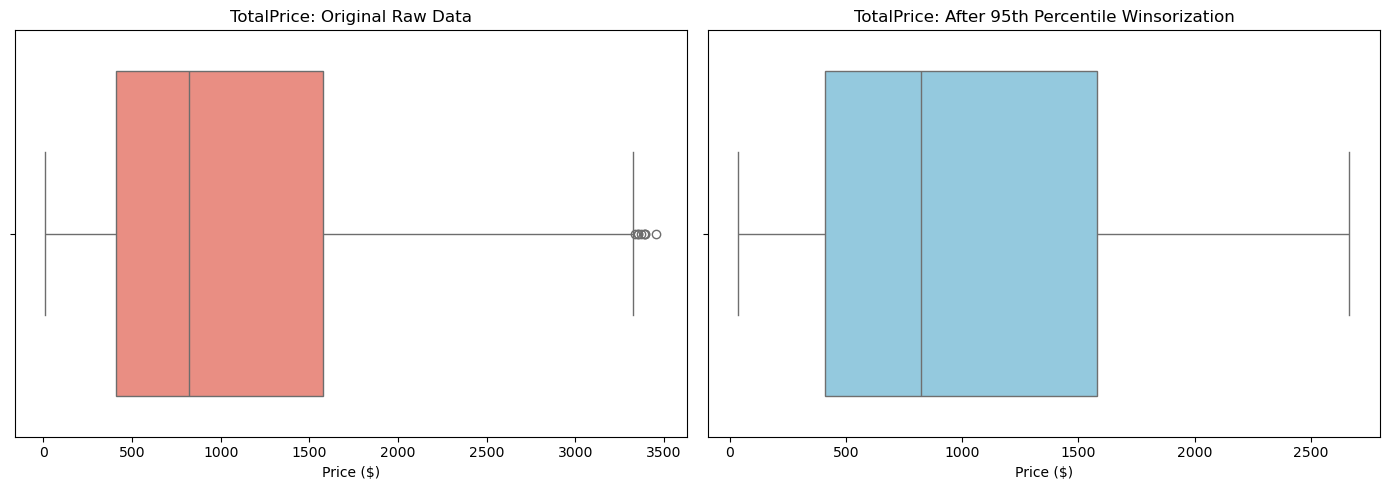

In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. RELOAD your raw data here so we have the original outliers back
# (Replace 'your_data_file.csv' with your actual file path/code)
data_raw = pd.read_csv('Dataset for Data Analytics - Sheet1.csv') 

# 2. Create a clean copy and apply Winsorization to the COPY only
data_clean = data_raw.copy()

# Let's cap at the 95th percentile to make it highly visible
lower_bound = data_raw['TotalPrice'].quantile(0.01)
upper_bound = data_raw['TotalPrice'].quantile(0.95)

data_clean['TotalPrice'] = np.clip(data_raw['TotalPrice'], lower_bound, upper_bound)

# 3. Plot them side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot RAW data (with the original giant outliers)
sns.boxplot(ax=axes[0], x=data_raw['TotalPrice'], color='salmon')
axes[0].set_title('TotalPrice: Original Raw Data')
axes[0].set_xlabel('Price ($)')

# Plot CLEANED data (capped at 95th percentile)
sns.boxplot(ax=axes[1], x=data_clean['TotalPrice'], color='skyblue')
axes[1].set_title('TotalPrice: After 95th Percentile Winsorization')
axes[1].set_xlabel('Price ($)')

plt.tight_layout()
plt.show()

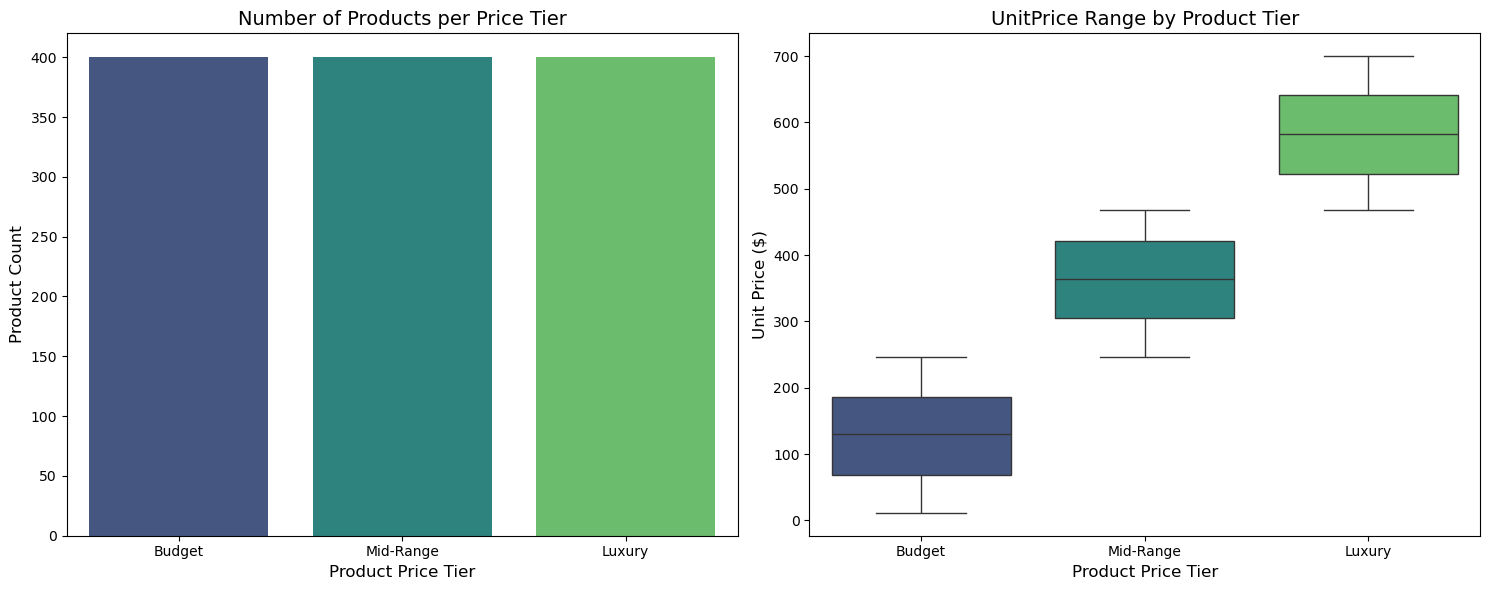

In [84]:
data_clean['Product_Price_Tier'] = pd.qcut(data_clean['UnitPrice'], q=3, labels=['Budget', 'Mid-Range', 'Luxury'])

import matplotlib.pyplot as plt
import seaborn as sns

# Create a side-by-side plot
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Chart 1: Count of Products in each Tier (Bar Chart)
sns.countplot(
    ax=axes[0], 
    data=data_clean, 
    x='Product_Price_Tier', 
    palette='viridis',
    hue='Product_Price_Tier',
    legend=False
)
axes[0].set_title('Number of Products per Price Tier', fontsize=14)
axes[0].set_xlabel('Product Price Tier', fontsize=12)
axes[0].set_ylabel('Product Count', fontsize=12)

# Chart 2: Price Range by Tier (Box Plot to show the separation)
sns.boxplot(
    ax=axes[1], 
    data=data_clean, 
    x='Product_Price_Tier', 
    y='UnitPrice', 
    palette='viridis',
    hue='Product_Price_Tier',
    legend=False
)
axes[1].set_title('UnitPrice Range by Product Tier', fontsize=14)
axes[1].set_xlabel('Product Price Tier', fontsize=12)
axes[1].set_ylabel('Unit Price ($)', fontsize=12)

plt.tight_layout()
plt.show()